In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

print("\n✅ ALL LIBRARIES ARE WORKING!")

NumPy: 2.2.6
Pandas: 2.3.1
Matplotlib: 3.10.3
Scikit-learn: 1.7.1

✅ ALL LIBRARIES ARE WORKING!


In [2]:
data = {
    "Temperature": [
        4, 5, 6, 8, 10, 12, 15, 18, 20, 22,
        25, 28, 30, 32, 35, 4, 7, 11, 16, 24,
        27, 31, 33, 36, 9, 13, 19, 21, 26, 29,
        3, 6, 9, 14, 17, 23, 26, 30, 34, 37
    ],

    "Humidity": [
        45, 50, 55, 60, 65, 70, 75, 80, 82, 85,
        88, 90, 92, 94, 95, 48, 58, 68, 78, 86,
        89, 93, 96, 97, 62, 72, 81, 84, 91, 94,
        40, 52, 64, 73, 79, 87, 90, 93, 96, 98
    ],

    "Days_Stored": [
        1, 1, 2, 2, 3, 3, 4, 4, 5, 5,
        6, 6, 7, 7, 8, 1, 2, 3, 4, 5,
        6, 7, 8, 9, 2, 3, 5, 5, 7, 8,
        1, 2, 3, 4, 4, 6, 7, 8, 9, 10
    ],

    "Gas_Level": [
        10, 12, 15, 18, 20, 25, 30, 35, 40, 45,
        50, 55, 60, 65, 70, 11, 16, 22, 32, 48,
        53, 62, 72, 78, 19, 27, 38, 44, 58, 68,
        8, 14, 23, 31, 36, 49, 57, 67, 76, 82
    ],

    "Spoiled": [
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print("Dataset Created Successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df

Dataset Created Successfully!
Rows: 40
Columns: 5


,Temperature,Humidity,Days_Stored,Gas_Level,Spoiled
0,4,45,1,10,0
1,5,50,1,12,0
2,6,55,2,15,0
3,8,60,2,18,0
4,10,65,3,20,0
5,12,70,3,25,0
6,15,75,4,30,0
7,18,80,4,35,0
8,20,82,5,40,0
9,22,85,5,45,0


In [3]:
print("Dataset Information")
print("=" * 40)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Temperature  40 non-null     int64
 1   Humidity     40 non-null     int64
 2   Days_Stored  40 non-null     int64
 3   Gas_Level    40 non-null     int64
 4   Spoiled      40 non-null     int64
dtypes: int64(5)
memory usage: 1.7 KB


In [4]:
print("Missing Values")
print("=" * 40)

print(df.isnull().sum())

Missing Values
Temperature    0
Humidity       0
Days_Stored    0
Gas_Level      0
Spoiled        0
dtype: int64


In [5]:
df.describe()

,Temperature,Humidity,Days_Stored,Gas_Level,Spoiled
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,19.375000,77.375000,4.825000,41.025000,0.425000
std,10.455492,16.625108,2.530709,21.925851,0.500641
min,3.000000,40.000000,1.000000,8.000000,0.000000
25%,9.750000,64.750000,3.000000,21.500000,0.000000
50%,19.500000,81.500000,5.000000,39.000000,0.000000
75%,28.250000,91.250000,7.000000,58.500000,1.000000
max,37.000000,98.000000,10.000000,82.000000,1.000000


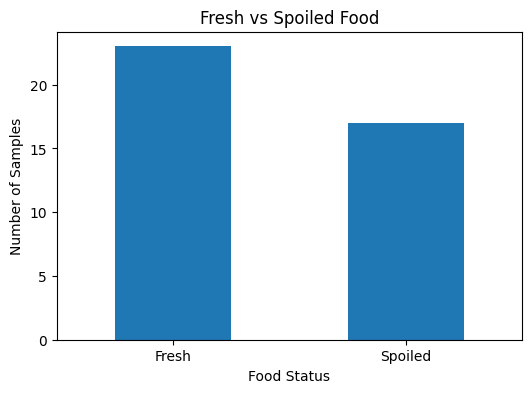

In [6]:
plt.figure(figsize=(6, 4))

df["Spoiled"].value_counts().plot(kind="bar")

plt.title("Fresh vs Spoiled Food")
plt.xlabel("Food Status")
plt.ylabel("Number of Samples")

plt.xticks(
    [0, 1],
    ["Fresh", "Spoiled"],
    rotation=0
)

plt.show()

In [7]:
X = df[
    [
        "Temperature",
        "Humidity",
        "Days_Stored",
        "Gas_Level"
    ]
]

y = df["Spoiled"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   Temperature  Humidity  Days_Stored  Gas_Level
0            4        45            1         10
1            5        50            1         12
2            6        55            2         15
3            8        60            2         18
4           10        65            3         20

Target:
0    0
1    0
2    0
3    0
4    0
Name: Spoiled, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 32
Testing Samples: 8


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest Model Created!")

Random Forest Model Created!


In [10]:
model.fit(X_train, y_train)

print("✅ Model Training Completed!")

✅ Model Training Completed!


In [11]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[0 0 0 1 0 1 0 1]

Predicted Values:
[0 0 0 1 0 1 0 1]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:")
print(round(accuracy * 100, 2), "%")

Model Accuracy:
100.0 %


In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fresh", "Spoiled"]
    )
)

              precision    recall  f1-score   support

       Fresh       1.00      1.00      1.00         5
     Spoiled       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[5 0]
 [0 3]]


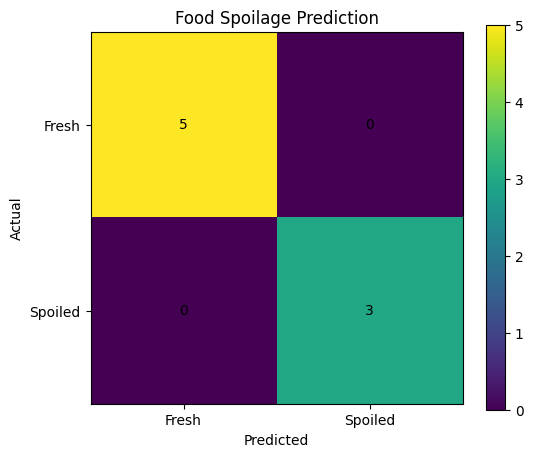

In [15]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Food Spoilage Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Fresh", "Spoiled"])
plt.yticks([0, 1], ["Fresh", "Spoiled"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

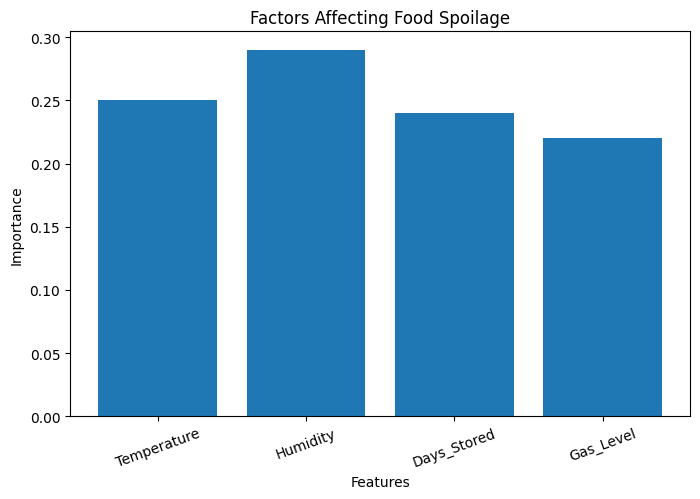

In [16]:
importance = model.feature_importances_

plt.figure(figsize=(8, 5))

plt.bar(
    X.columns,
    importance
)

plt.title("Factors Affecting Food Spoilage")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=20)

plt.show()

In [17]:
print("=" * 50)
print("   AI FOOD SPOILAGE PREDICTION SYSTEM")
print("=" * 50)

temperature = float(
    input("Enter Temperature (°C): ")
)

humidity = float(
    input("Enter Humidity (%): ")
)

days = int(
    input("Enter Days Stored: ")
)

gas = float(
    input("Enter Gas Level: ")
)

new_food = pd.DataFrame({
    "Temperature": [temperature],
    "Humidity": [humidity],
    "Days_Stored": [days],
    "Gas_Level": [gas]
})

prediction = model.predict(new_food)

probability = model.predict_proba(new_food)

print("\n" + "=" * 50)

if prediction[0] == 0:
    print("Food Status : FRESH")
else:
    print("Food Status : SPOILED")

print(
    "Fresh Probability   :",
    round(probability[0][0] * 100, 2),
    "%"
)

print(
    "Spoiled Probability :",
    round(probability[0][1] * 100, 2),
    "%"
)

print("=" * 50)

   AI FOOD SPOILAGE PREDICTION SYSTEM


Enter Temperature (°C):  30
Enter Humidity (%):  90
Enter Days Stored:  7
Enter Gas Level:  60



Food Status : SPOILED
Fresh Probability   : 0.0 %
Spoiled Probability : 100.0 %


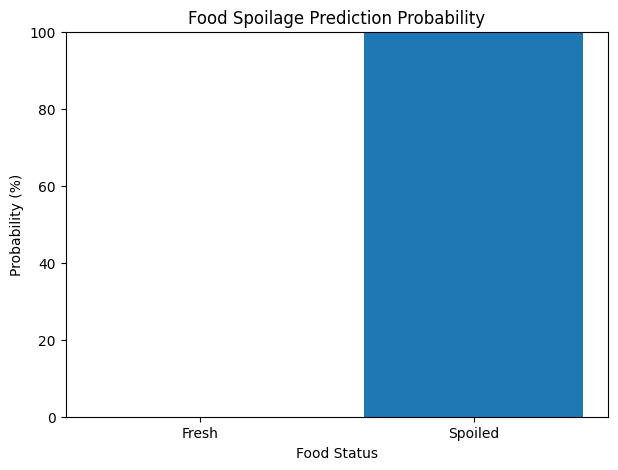

In [18]:
labels = ["Fresh", "Spoiled"]

probabilities = [
    probability[0][0] * 100,
    probability[0][1] * 100
]

plt.figure(figsize=(7, 5))

plt.bar(labels, probabilities)

plt.title("Food Spoilage Prediction Probability")
plt.xlabel("Food Status")
plt.ylabel("Probability (%)")

plt.ylim(0, 100)

plt.show()